<Axes: xlabel='report_date'>

<Figure size 10000x10000 with 0 Axes>

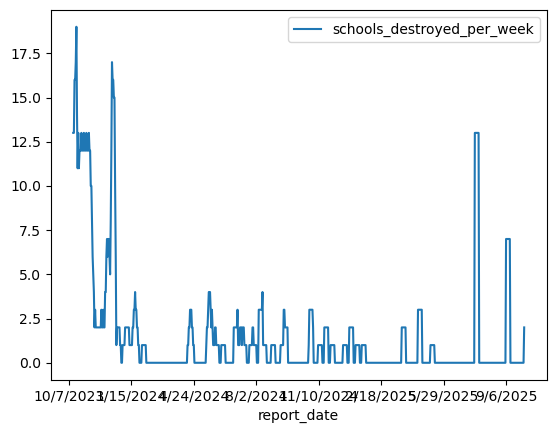

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
merged = pd.read_csv('Gaza Casualties and Infrastructure Damage Dataset.csv')
# Analysis
plt.figure(figsize = (100,100))
merged['schools_destroyed_per_week'] = merged['educational_buildings.ext_destroyed'].diff(7)
merged.plot(x='report_date', y='schools_destroyed_per_week', kind='line')

In [17]:
merged['day_of_week'] = pd.to_datetime(merged['report_date']).dt.dayofweek
weekly_pattern = merged.groupby('day_of_week')['killed_children_cum'].diff().mean()

KeyError: 'Column not found: killed_children_cum'

In [18]:
merged['percent_schools_destroyed'] = (merged['educational_buildings.ext_destroyed'] / 650) * 100
tipping_point = merged[merged['percent_schools_destroyed'] > 50]['report_date'].iloc[0]

IndexError: single positional indexer is out-of-bounds

In [19]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation
correlation, p_value = pearsonr(
    merged['educational_buildings.ext_destroyed'],
    merged['killed_children_cum']
)

# Spearman rank correlation (non-parametric)
spearman_corr, spearman_p = spearmanr(
    merged['educational_buildings.ext_destroyed'],
    merged['killed_children_cum']
)

KeyError: 'killed_children_cum'